# Poisson Regression with Aurora-GLM

This notebook demonstrates Poisson regression for count data using Aurora-GLM.

Poisson regression is used when the response variable represents counts or rates. It assumes:
- The response follows a Poisson distribution
- The log of the expected count is a linear combination of predictors

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from aurora.models.glm import fit_glm

# Set random seed for reproducibility
rng = np.random.default_rng(42)

## Generate Synthetic Count Data

We'll simulate count data where the counts depend on two predictors.

In [2]:
# Generate predictors
n_samples = 200
X = rng.normal(size=(n_samples, 2))
X[:, 0] = X[:, 0] * 0.5  # Scale first predictor

# True coefficients
true_coef = np.array([0.8, -0.5])
true_intercept = 1.2

# Generate counts using Poisson distribution
linear_predictor = true_intercept + X @ true_coef
expected_counts = np.exp(linear_predictor)
y = rng.poisson(expected_counts)

print(f"Generated {n_samples} samples")
print(f"Response range: [{y.min()}, {y.max()}]")
print(f"Mean count: {y.mean():.2f}")

Generated 200 samples
Response range: [0, 22]
Mean count: 4.03


## Visualize the Data

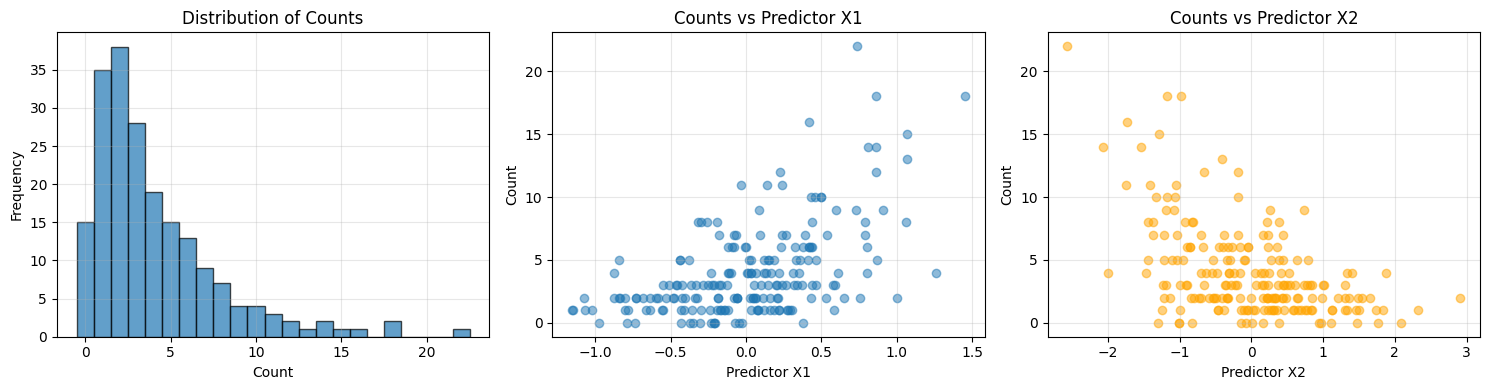

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram of counts
axes[0].hist(y, bins=np.arange(y.max() + 2) - 0.5, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Counts')
axes[0].grid(alpha=0.3)

# Scatter plot: X1 vs y
axes[1].scatter(X[:, 0], y, alpha=0.5)
axes[1].set_xlabel('Predictor X1')
axes[1].set_ylabel('Count')
axes[1].set_title('Counts vs Predictor X1')
axes[1].grid(alpha=0.3)

# Scatter plot: X2 vs y
axes[2].scatter(X[:, 1], y, alpha=0.5, color='orange')
axes[2].set_xlabel('Predictor X2')
axes[2].set_ylabel('Count')
axes[2].set_title('Counts vs Predictor X2')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Fit Poisson GLM

We'll fit a Poisson regression model with log link (the canonical link).

In [4]:
# Fit the model
result = fit_glm(X, y, family='poisson', link='log')

print("Model converged:", result.converged_)
print(f"Number of iterations: {result.n_iter_}")
print(f"\nEstimated intercept: {result.intercept_:.4f} (true: {true_intercept:.4f})")
print(f"Estimated coefficients: {result.coef_}")
print(f"True coefficients: {true_coef}")

Model converged: True
Number of iterations: 5

Estimated intercept: 1.1535 (true: 1.2000)
Estimated coefficients: [ 0.92994207 -0.49716222]
True coefficients: [ 0.8 -0.5]


## Model Summary

Aurora-GLM provides R-style summary tables with coefficient estimates, standard errors, z-scores, and p-values.

In [5]:
print(result.summary())

                       Generalized Linear Model Results                       
Family:                   Poisson                    Link function:  Log
No. Observations:         200                        Df Residuals:   197
Df Model:                 2                         
Converged:                Yes                        No. Iterations: 5
                   coef    std err          z      P>|z|     [0.025     0.975]
------------------------------------------------------------------------------
   intercept     1.1535     0.0423     27.267      1.000     1.0706     1.2364 
          X0     0.9299     0.0685     13.579      0.000     0.7957     1.0642 ***
          X1    -0.4972     0.0384    -12.957      0.000    -0.5724    -0.4220 ***
Significance codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Deviance:                               224.59 Null Deviance:           601.40
AIC:                                    230.59 BIC:                     240.49
Pseudo R-squared:     

## Model Diagnostics

We can inspect model fit quality using diagnostic plots.

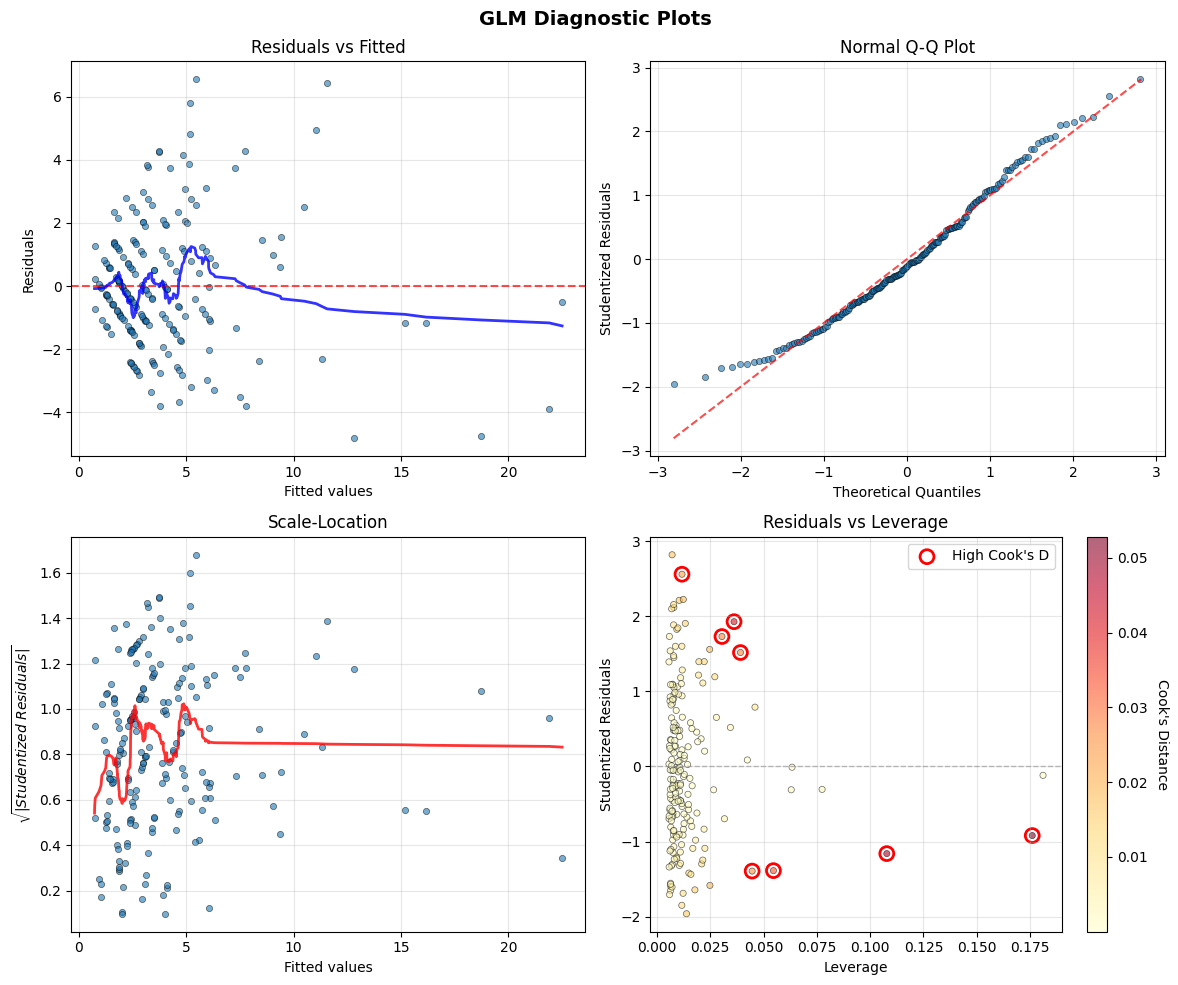

In [6]:
# Generate diagnostic plots
fig = result.plot_diagnostics(figsize=(12, 10))
plt.show()

## Predictions

Generate predictions on the response scale (expected counts) and link scale (log-counts).

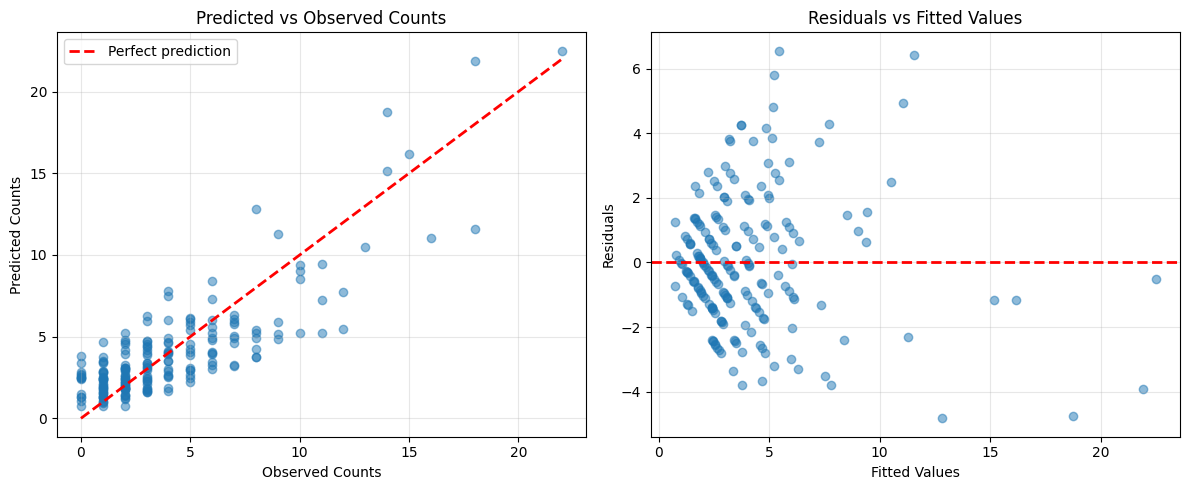

Mean Absolute Error: 1.5773


In [7]:
# Predictions on response scale
y_pred = result.predict(X, type='response')

# Predictions on link scale
y_pred_link = result.predict(X, type='link')

# Visualize predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Predicted vs actual (response scale)
axes[0].scatter(y, y_pred, alpha=0.5)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Observed Counts')
axes[0].set_ylabel('Predicted Counts')
axes[0].set_title('Predicted vs Observed Counts')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuals vs fitted
residuals = y - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Fitted Values')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate mean absolute error
mae = np.mean(np.abs(residuals))
print(f"Mean Absolute Error: {mae:.4f}")

## Model Comparison

Let's compare the Poisson model with a Gaussian model to see why Poisson is more appropriate for count data.

In [8]:
# Fit Gaussian GLM for comparison
result_gaussian = fit_glm(X, y, family='gaussian')

print("Poisson GLM:")
print(f"  AIC: {result.aic_:.2f}")
print(f"  Deviance: {result.deviance_:.2f}")
print(f"  Null Deviance: {result.null_deviance_:.2f}")

print("\nGaussian GLM:")
print(f"  AIC: {result_gaussian.aic_:.2f}")
print(f"  Deviance: {result_gaussian.deviance_:.2f}")
print(f"  Null Deviance: {result_gaussian.null_deviance_:.2f}")

print(f"\nPoisson model has {'lower' if result.aic_ < result_gaussian.aic_ else 'higher'} AIC (better fit)")

Poisson GLM:
  AIC: 230.59
  Deviance: 224.59
  Null Deviance: 601.40

Gaussian GLM:
  AIC: 1119.07
  Deviance: 1113.07
  Null Deviance: 2775.82

Poisson model has lower AIC (better fit)


## Conclusion

This notebook demonstrated:
1. Generating synthetic count data
2. Fitting a Poisson GLM with Aurora-GLM
3. Viewing model summaries and diagnostics
4. Making predictions
5. Comparing model fit quality

Poisson regression is ideal for count data and provides better model fit than Gaussian regression for this type of response variable.